RANDOM FOREST

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

from pickle import dump

In [29]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [31]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())

In [32]:
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [33]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      27.334635   94.652344   
std    

In [34]:

df = df[df['Pregnancies'] <= 12]
df = df[(df['Glucose']>=70) & (df['Glucose'] <=140)]
df = df[(df['BloodPressure'] >= 70) & (df['BloodPressure'] <= 120)]
df = df[(df['SkinThickness'] >= 10) & (df['SkinThickness'] <= 60)]
df = df[df['Insulin'] <= 400] 
df = df[(df['BMI'] >= 18.5) & (df['BMI'] <= 40)]     
df = df[df['DiabetesPedigreeFunction'] <= 2]
df = df[(df['Age'] >= 20) & (df['Age'] <= 80)]

In [35]:
print("Número de personas con y sin diabetes:")
print(df["Outcome"].value_counts())

Número de personas con y sin diabetes:
Outcome
0    209
1     70
Name: count, dtype: int64


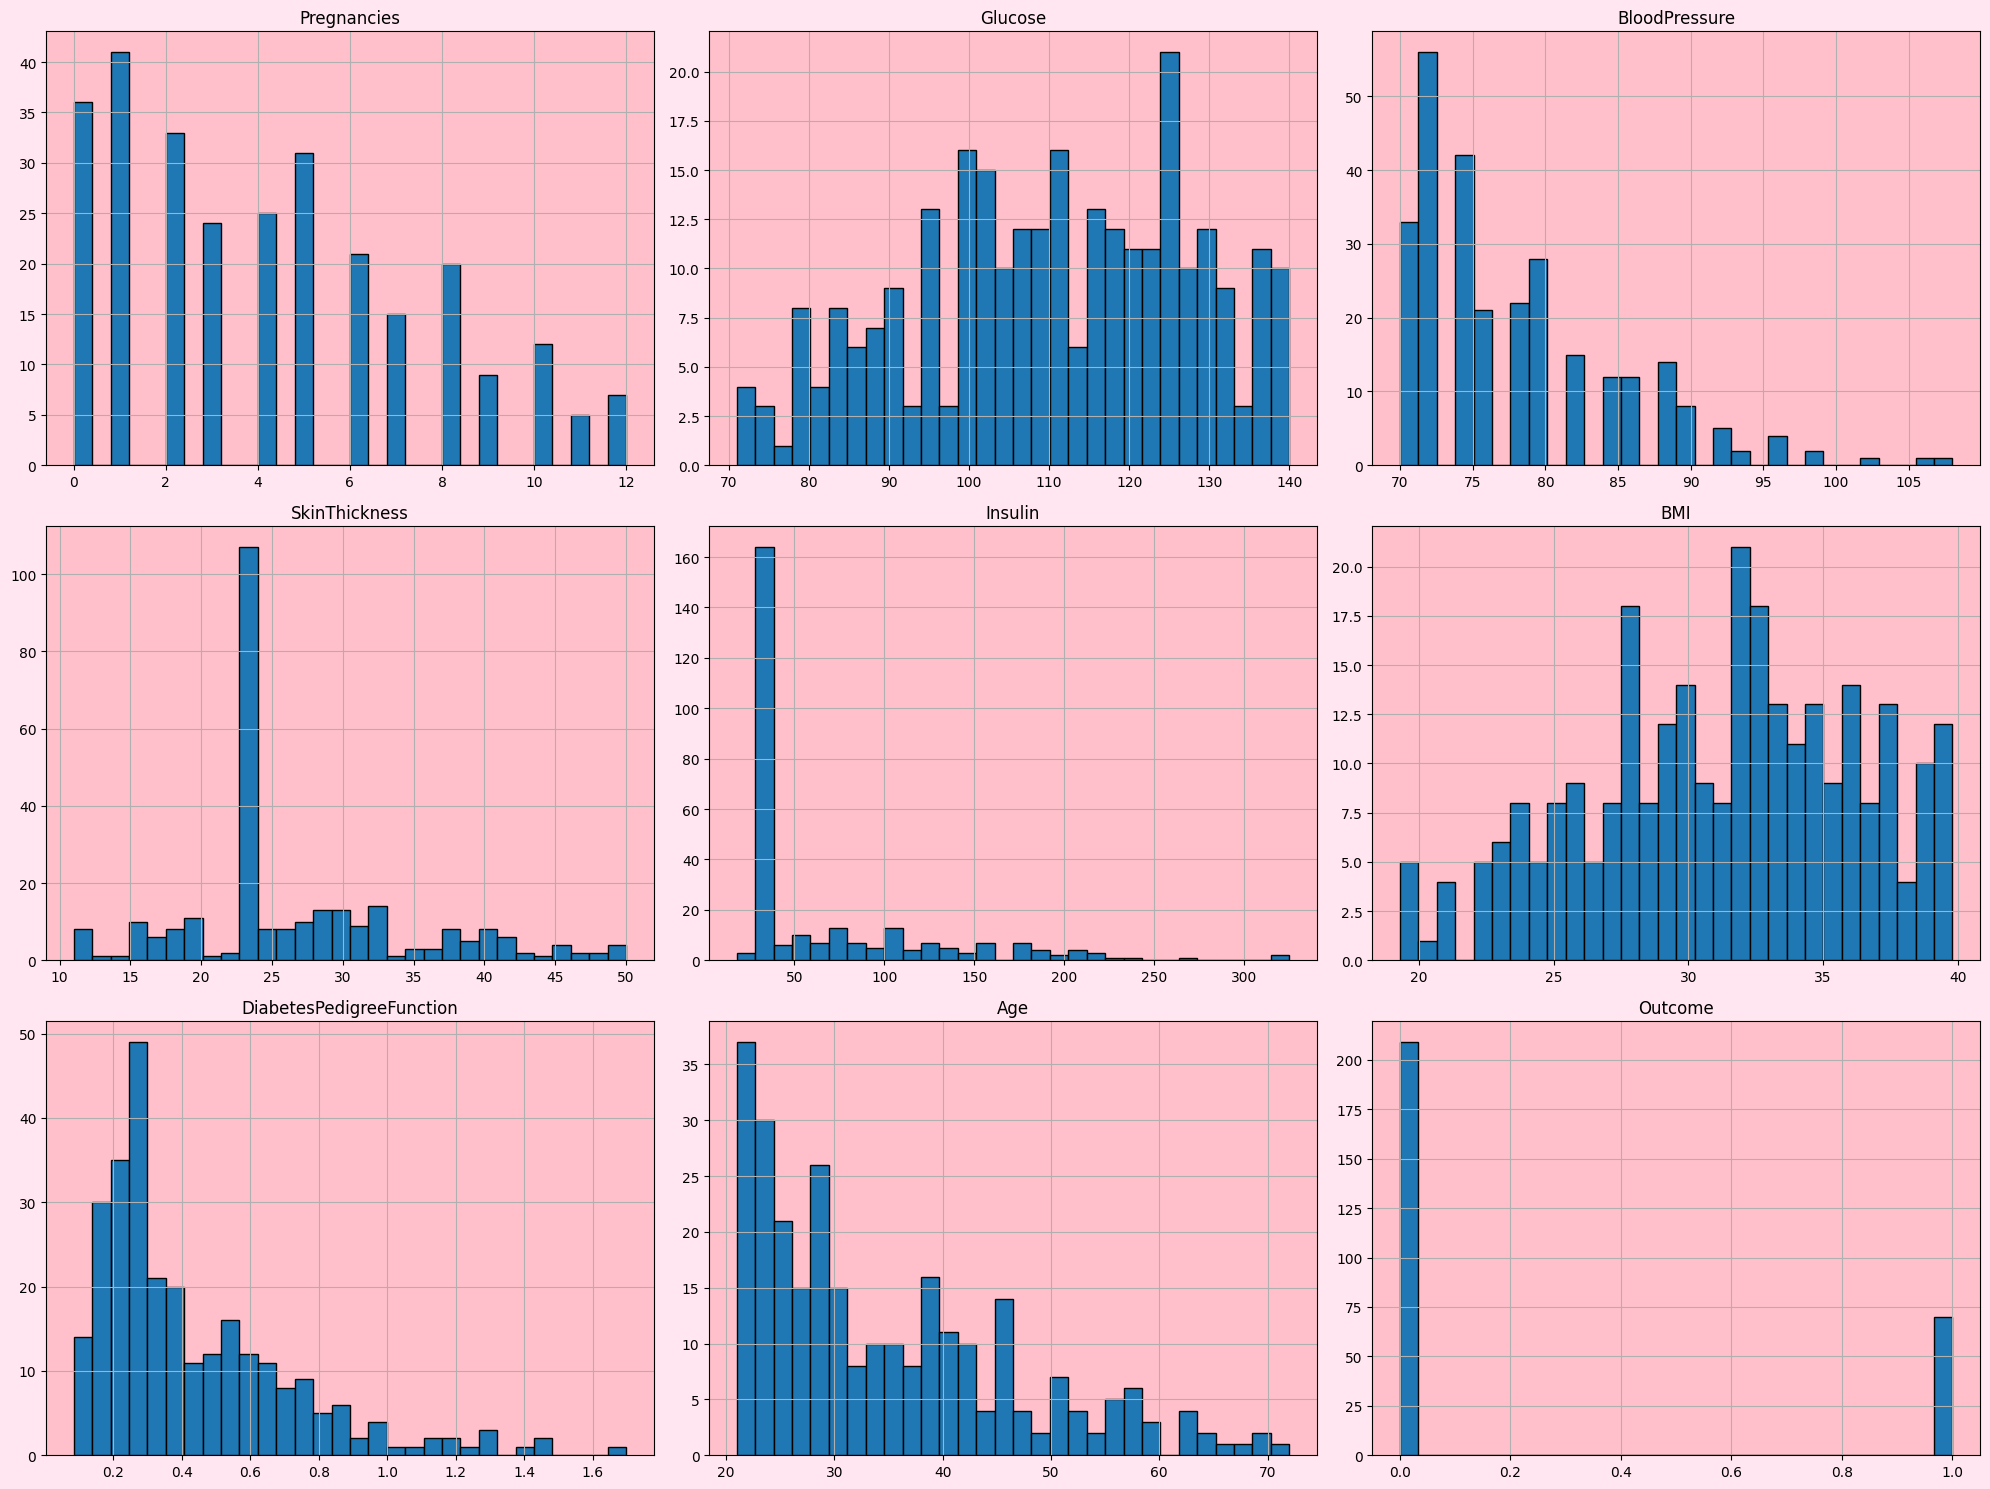

In [36]:
plt.style.use('default') 
fig = df.hist(figsize=(20, 15), bins=30, edgecolor='black')


for ax in fig.flatten():
    ax.set_facecolor('pink')  

plt.gcf().patch.set_facecolor('#ffe6f0') 

plt.tight_layout()
plt.show()

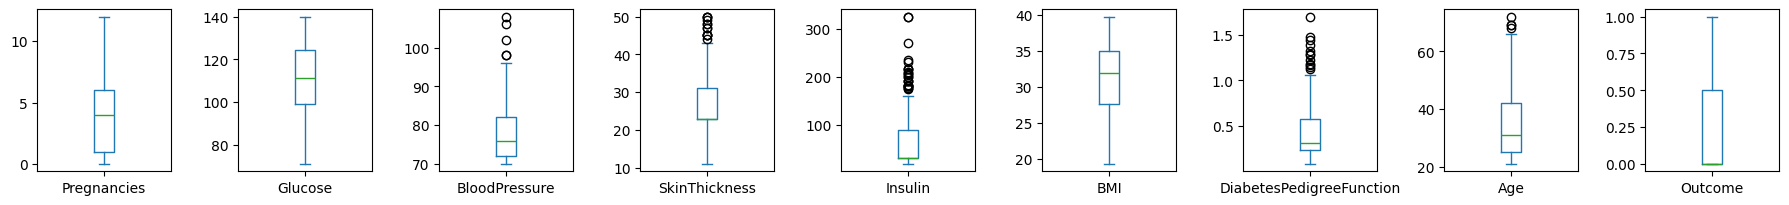

In [37]:
df.plot(kind='box', subplots=True, layout=(10, 10), figsize=(20, 20), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

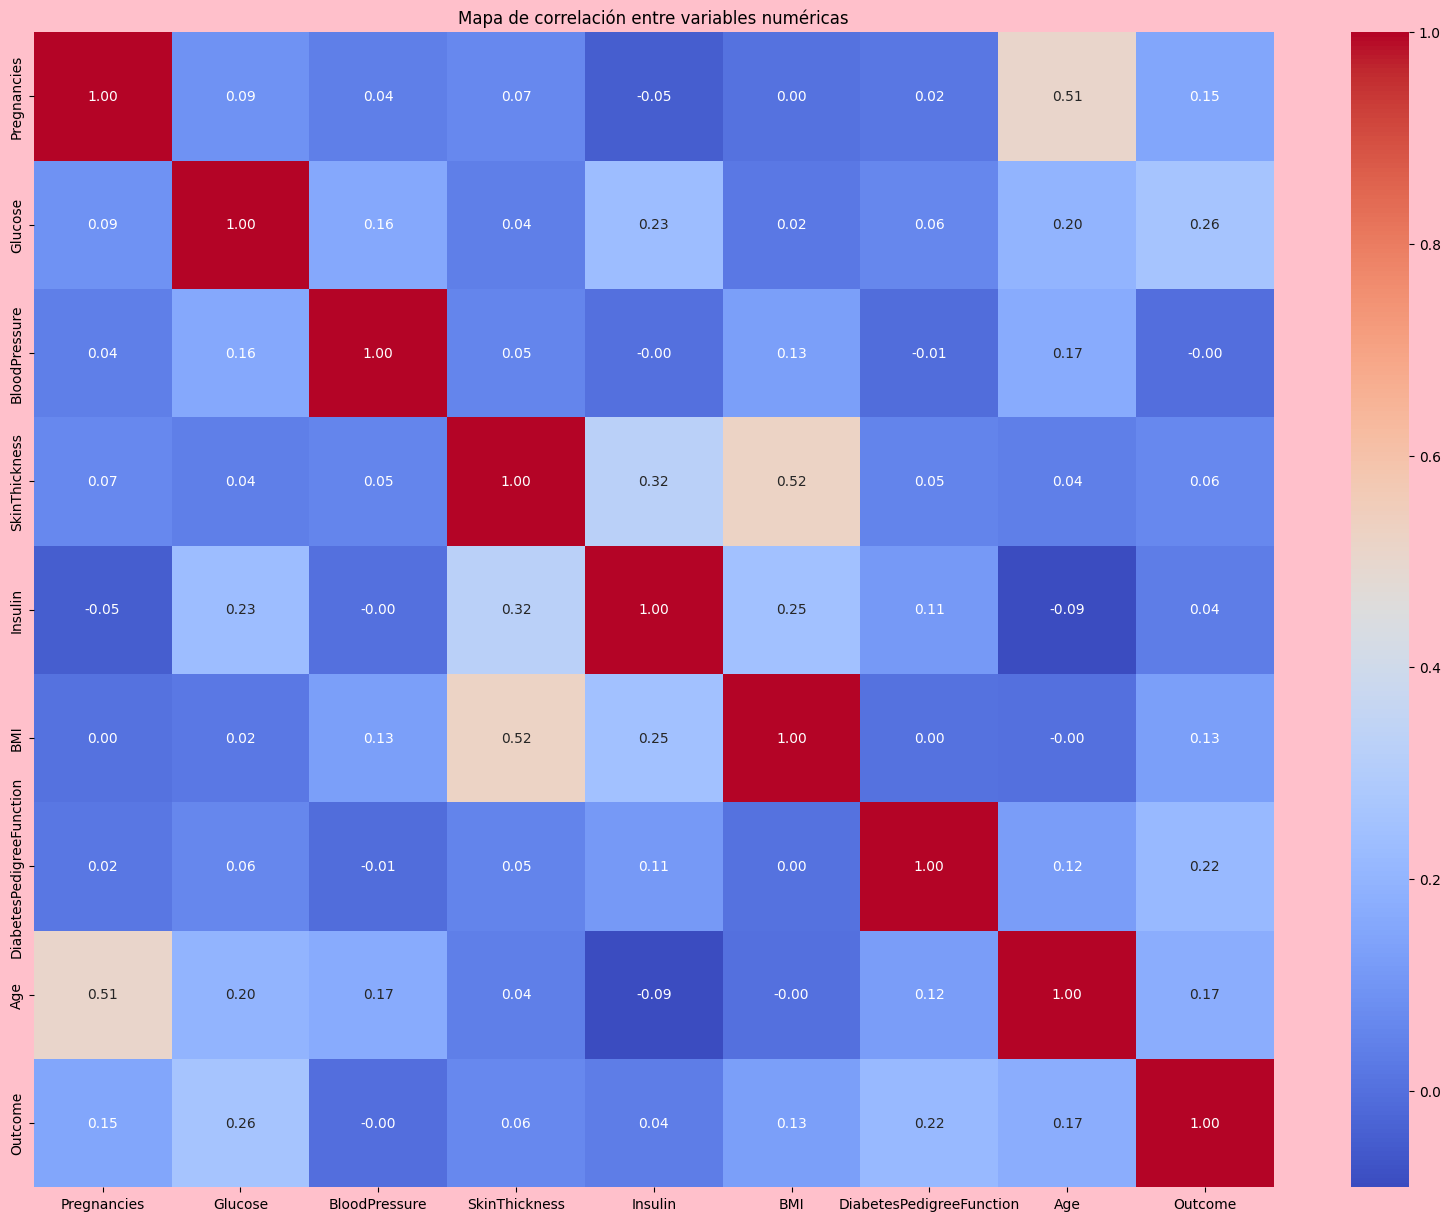

In [38]:
plt.figure(figsize=(20, 15),facecolor="pink")
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Mapa de correlación entre variables numéricas")
plt.show()

In [39]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

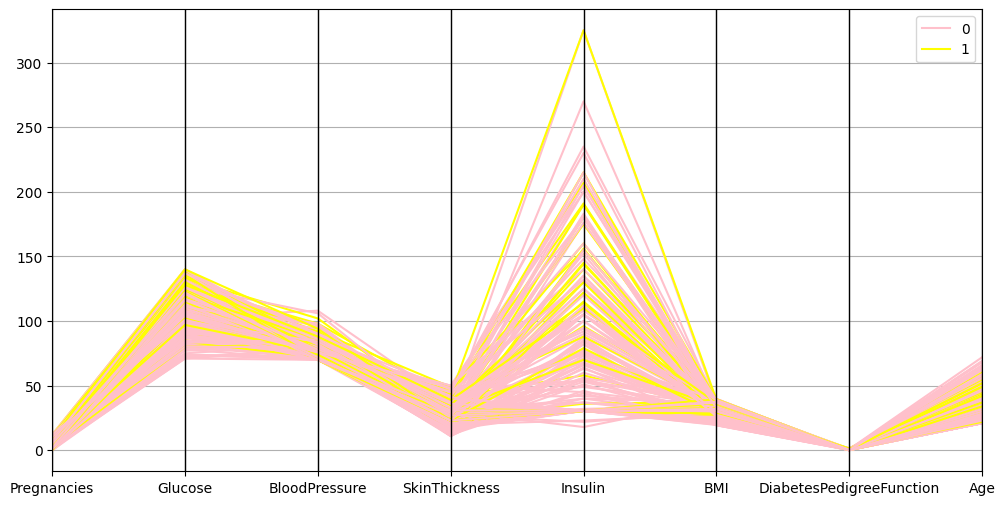

In [40]:
plt.figure(figsize=(12,6))
pd.plotting.parallel_coordinates(df, "Outcome", color = ("pink", "yellow"))
plt.show()

In [42]:
X = df.drop("Outcome", axis=1)  
y = df["Outcome"] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_sel = X_train.copy() 
X_test_sel = X_test.copy()   


X_train_sel["Outcome"] = y_train.values 
X_test_sel["Outcome"] = y_test.values   


X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

X_train_sel.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
726,1,116,78,29,180.0,36.1,0.496,25,0
375,12,140,82,43,325.0,39.2,0.528,58,1
91,4,123,80,15,176.0,32.0,0.443,34,0
265,5,96,74,18,67.0,33.6,0.997,43,0
736,0,126,86,27,120.0,27.4,0.515,21,0


In [43]:
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]
X_test = test_data.drop(["Outcome"], axis=1)
y_test = test_data["Outcome"]

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 60, random_state = 42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=60, random_state=42)

In [45]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1])

In [46]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8035714285714286

In [47]:
from pickle import dump

dump(model, open("../models/ranfor_classifier_nestimators-60_42.sav", "wb"))